In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# LOADING DATA

orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
categories = pd.read_csv("product_category_name_translation.csv")

# DATA UNDERSTANDING

In [33]:
# QUICK CHECK OF THE DATAFRAMES

for name, df in {
    "orders": orders,
    "items": items,
    "customers": customers,
    "payments": payments,
    "products": products,
    "categories": categories
}.items():
    print(f"{name}: {df.shape}")


print("\n")
print(orders.info(), "\n")
print(items.info(), "\n")
print(customers.info(), "\n")
print(payments.info(), "\n")
print(products.info(), "\n")
print(categories.info(), "\n")


orders: (99441, 8)
items: (112650, 7)
customers: (99441, 5)
payments: (103886, 5)
products: (32951, 9)
categories: (71, 2)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](3), object(5)
memory usage: 6.1+ MB
None 

<class 'pandas.core.frame.DataF

# DATA CLEANING

In [34]:
# CONVERTING DATE COLUMNS TO DATETIME

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

In [7]:
# FILTERING ONLY DELIVERED ORDERS

orders_delivered = orders[orders["order_status"] == "delivered"].copy()

In [35]:
# CHECKING FOR MISSING VALUES IN THE DELIVERED ORDERS DATAFRAME

orders_delivered.isna().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64

In [ ]:
# CHECKING FOR DUPLICATES IN THE DATAFRAMES

print("Duplicated orders:", orders_delivered.duplicated().sum())
print("Duplicated order items:", items.duplicated().sum())
print("Duplicated customers:", customers.duplicated().sum())

Duplicated orders: 0
Duplicated order items: 0
Duplicated customers: 0


In [36]:
# CHECKING OULIERS IN THE PRICE COLUMN OF THE ITEMS DATAFRAME

print(items["price"].describe(), "\n")

items[items["price"] > items["price"].quantile(0.99)][
    ["order_id", "product_id", "price", "freight_value"]
].sort_values("price", ascending=False).head(10)

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64 



,order_id,product_id,price,freight_value
3556,0812eb902a67711a1cb742b3cdaa65ae,489ae2aa008f021502940f251d4cce7f,6735.00,194.31
112233,fefacc66af859508bf1a7934eab1e97f,69c590f7ffc7bf8db97190b6cb6ed62e,6729.00,193.21
107841,f5136e38d1a14a4dbd87dff67da82701,1bdf5e6731585cf01aa8169c7028d6ad,6499.00,227.66
74336,a96610ab360d42a2e5335a3998b4718a,a6492cc69376c469ab6f61d8f44de961,4799.00,151.34
11249,199af31afc78c699f0dbf71fb178d4d4,c3ed642d592594bb648ff4a04cee2747,4690.00,74.34
62086,8dbc85d1447242f3b127dda390d56e19,259037a6a41845e455183f89c5035f18,4590.00,91.78
29193,426a9742b533fc6fed17d1fd6d143d7e,a1beef8f3992dbd4cd8726796aa69c53,4399.87,113.45
45843,68101694e5c5dc7330c91e1bbc36214f,6cdf8fc1d741c76586d8b6b15e9eef30,4099.99,75.27
78310,b239ca7cd485940b31882363b52e6674,dd113cb02b2af9c8e5787e8f1f0722f6,4059.00,104.51
59137,86c4eab1571921a6a6e248ed312f5a5a,6902c1962dd19d540807d0ab8fade5c6,3999.90,17.01


In [37]:
# CREATING ANALYTICAL DATASET

df = (
    orders_delivered
    .merge(customers, on="customer_id", how="left")
    .merge(items, on="order_id", how="left")
    .merge(products, on="product_id", how="left")
    .merge(categories, on="product_category_name", how="left")
)

df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)
df["order_date"] = df["order_purchase_timestamp"].dt.date
df["revenue"] = df["price"]
df["freight"] = df["freight_value"]

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  object        
 1   customer_id                    110197 non-null  object        
 2   order_status                   110197 non-null  object        
 3   order_purchase_timestamp       110197 non-null  datetime64[ns]
 4   order_approved_at              110182 non-null  object        
 5   order_delivered_carrier_date   110195 non-null  object        
 6   order_delivered_customer_date  110189 non-null  datetime64[ns]
 7   order_estimated_delivery_date  110197 non-null  datetime64[ns]
 8   customer_unique_id             110197 non-null  object        
 9   customer_zip_code_prefix       110197 non-null  int64         
 10  customer_city                  110197 non-null  object        
 11  

# EDA

In [ ]:
# MAIN KPIs

total_revenue = df["revenue"].sum()
total_orders = df["order_id"].nunique()
total_customers = df["customer_unique_id"].nunique()
avg_order_value = total_revenue / total_orders

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value: {avg_order_value:,.2f}")

Total Revenue: 13,221,498.11
Total Orders: 96,478
Total Customers: 93,358
Average Order Value: 137.04


In [ ]:
# MONTHLY REVENUE TRENDS

monthly_sales = (
    df.groupby("order_month")
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique")
    )
    .reset_index()
)

monthly_sales.head()

,order_month,revenue,orders,customers
0,2016-09,134.97,1,1
1,2016-10,40325.11,265,262
2,2016-12,10.90,1,1
3,2017-01,111798.36,750,718
4,2017-02,234223.40,1653,1630


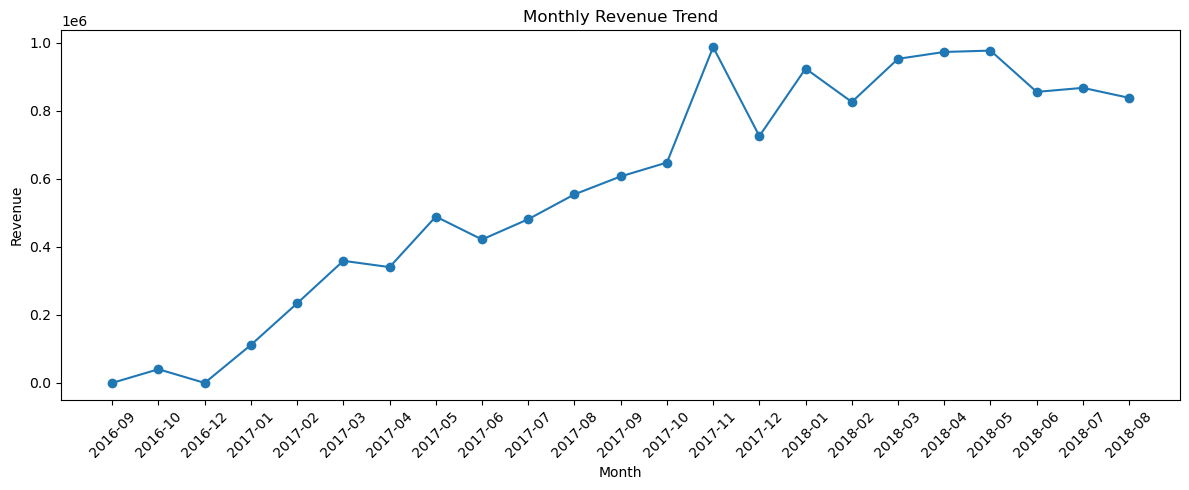

In [ ]:
# PLOTTING MONTHLY REVENUE TRENDS

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["order_month"], monthly_sales["revenue"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# TOP 10 PRODUCT CATEGORIES BY REVENUE

category_sales = (
    df.groupby("product_category_name_english")
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

category_sales.head(10)

,product_category_name_english,revenue,orders
43,health_beauty,1233131.72,8647
70,watches_gifts,1166176.98,5495
7,bed_bath_table,1023434.76,9272
65,sports_leisure,954852.55,7530
15,computers_accessories,888724.61,6530
39,furniture_decor,711927.69,6307
49,housewares,615628.69,5743
20,cool_stuff,610204.10,3559
5,auto,578966.65,3810
69,toys,471286.48,3804


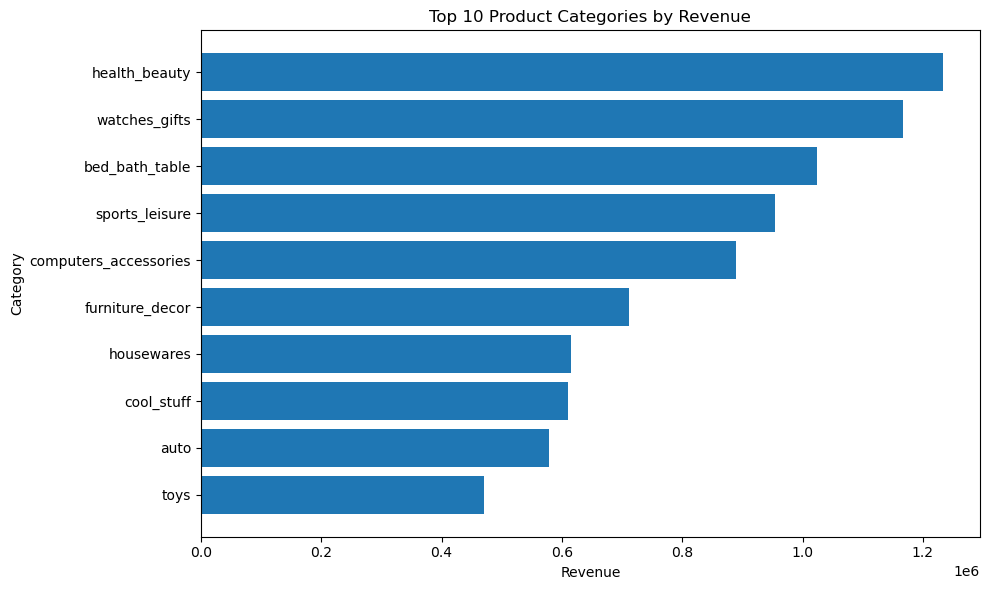

In [ ]:
# PLOTTING TOP 10 PRODUCT CATEGORIES BY REVENUE

top_categories = category_sales.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_categories["product_category_name_english"],
    top_categories["revenue"]
)
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# RFM CUSTOMER SEGMENTATION

reference_date = df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("customer_unique_id")
    .agg(
        last_order_date=("order_purchase_timestamp", "max"),
        frequency=("order_id", "nunique"),
        monetary=("revenue", "sum")
    )
    .reset_index()
)

rfm["recency"] = (
    reference_date - rfm["last_order_date"]
).dt.days

rfm = rfm[["customer_unique_id", "recency", "frequency", "monetary"]]

rfm.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
2,0000f46a3911fa3c0805444483337064,537,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00


In [ ]:
# CALCULATING RFM SCORES (1-5 SCALE FOR EACH METRIC)

rfm["r_score"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm["f_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["m_score"] = pd.qcut(
    rfm["monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["rfm_score"] = (
    rfm["r_score"].astype(str)
    + rfm["f_score"].astype(str)
    + rfm["m_score"].astype(str)
)

In [ ]:
# BUSINESS SEGMENTS BASED ON RFM SCORES

def assign_segment(row):
    r = int(row["r_score"])
    f = int(row["f_score"])
    m = int(row["m_score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 4 and f <= 2:
        return "New / Recent Customers"
    elif r <= 2 and f >= 4:
        return "At Risk Loyal Customers"
    elif m >= 4 and f <= 2:
        return "Big Spenders - Low Frequency"
    elif r <= 2 and f <= 2:
        return "Lost Customers"
    else:
        return "Regular Customers"

rfm["customer_segment"] = rfm.apply(assign_segment, axis=1)

rfm.head()

,customer_unique_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,customer_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,4,414,New / Recent Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1,411,New / Recent Customers
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1,1,2,112,Lost Customers
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,2,1,1,211,Lost Customers
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,2,1,5,215,Big Spenders - Low Frequency


In [ ]:
# SUMMARIZING CUSTOMER SEGMENTS WITH KEY METRICS

segment_summary = (
    rfm.groupby("customer_segment")
    .agg(
        customers=("customer_unique_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        total_revenue=("monetary", "sum"),
        avg_monetary=("monetary", "mean")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

segment_summary

,customer_segment,customers,avg_recency,avg_frequency,total_revenue,avg_monetary
5,Regular Customers,39282,200.111374,1.023879,4359922.47,110.990338
1,Big Spenders - Low Frequency,8543,336.523704,1.000000,2315978.14,271.096587
0,At Risk Loyal Customers,14803,394.933932,1.072080,2158022.69,145.782793
4,New / Recent Customers,14984,90.878404,1.000000,2087427.21,139.310412
2,Champions,6449,91.305784,1.172895,1778394.92,275.762897
3,Lost Customers,9297,395.967624,1.000000,521752.68,56.120542


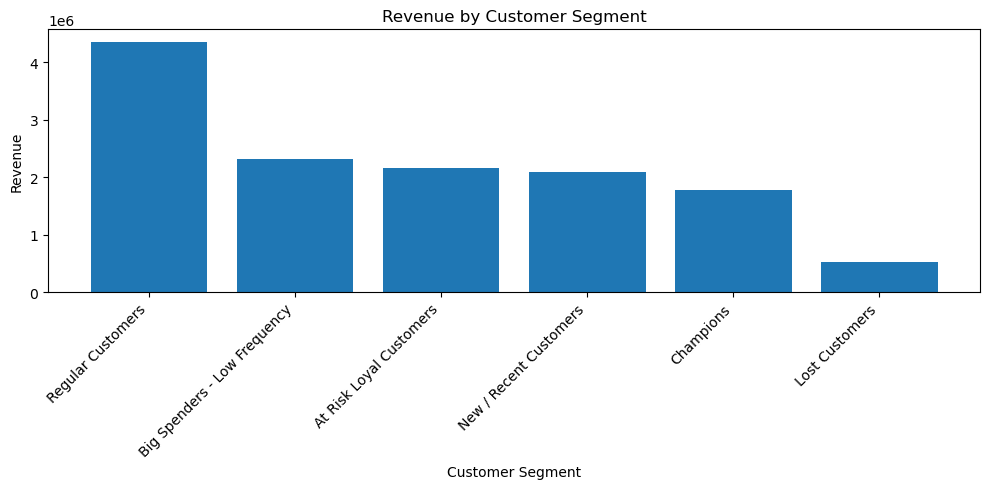

In [ ]:
# PLOTTING REVENUE BY CUSTOMER SEGMENT

plt.figure(figsize=(10, 5))
plt.bar(segment_summary["customer_segment"], segment_summary["total_revenue"])
plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Clustering KMeans

In [ ]:
# PREPARING AND SCALING DATA FOR KMEANS CLUSTERING

cluster_data = rfm[["recency", "frequency", "monetary"]].copy()

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

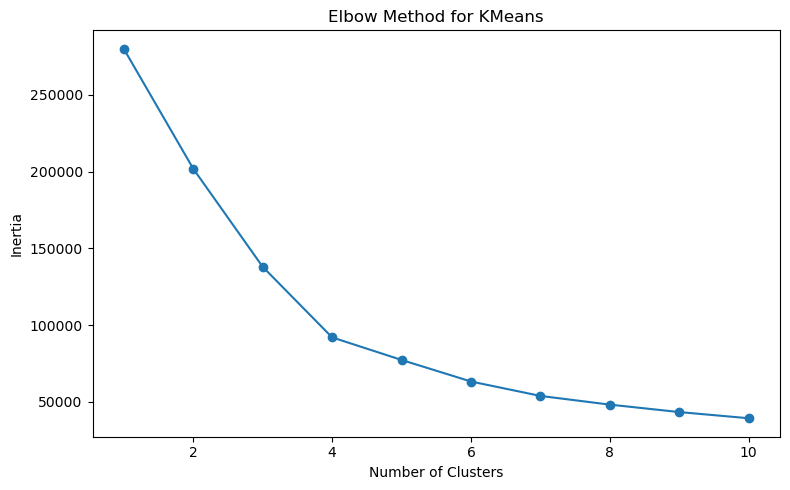

In [ ]:
# USING ELBOW METHOD TO DETERMINE OPTIMAL NUMBER OF CLUSTERS

inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(cluster_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker="o")
plt.title("Elbow Method for KMeans")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

In [ ]:
# FITTING KMEANS MODEL WITH 4 CLUSTERS AND ASSIGNING CLUSTER LABELS

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["cluster"] = kmeans.fit_predict(cluster_scaled)

In [ ]:
# SUMMARIZING CLUSTER CHARACTERISTICS AND PERFORMANCE METRICS

cluster_summary = (
    rfm.groupby("cluster")
    .agg(
        customers=("customer_unique_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        total_revenue=("monetary", "sum")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

cluster_summary

,cluster,customers,avg_recency,avg_frequency,avg_monetary,total_revenue
0,0,50746,128.071927,1.000000,113.373904,5753272.12
1,1,37649,387.338229,1.000000,114.049708,4293857.46
2,2,2189,237.681133,1.013248,1142.000566,2499839.24
3,3,2774,220.421413,2.114275,243.161244,674529.29


# Data export for dashboards

In [38]:
monthly_sales.to_csv("monthly_sales.csv", index=False)
category_sales.to_csv("category_sales.csv", index=False)
rfm.to_csv("rfm_customers.csv", index=False)
segment_summary.to_csv("segment_summary.csv", index=False)
cluster_summary.to_csv("cluster_summary.csv", index=False)